# Project 2 — Joint Detection of AI-Generated Images and Post-Processing Alterations




## Abstract

AI-generated image detectors are typically evaluated under idealized conditions, where images are clean, uncompressed, and sourced directly from generative models. In practice, images circulating on social media have often undergone post-processing, which can introduce degradation signatures and disrupt detector performance.

This project trains a unified multi-task deep learning framework that predicts both image authenticity and the applied post-processing setting.


## Dataset and Task

**Dataset:** RRDataset, containing real photographs and AI-generated images under three evaluation settings: original, internet-transmitted, and re-digitalized.

**Input:** one image.

**Outputs:**

- binary real/fake label;
- multi-class transformation label: original, transfer, redigital.

The multi-task model uses a shared backbone and two classification heads, trained with a weighted sum of two cross-entropy losses.


# 1. Imports

All packages used by the notebook project.


In [1]:
import os
import random
import tarfile
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128
CUDA available: True


# 2. Globals

Configuration variables used across the whole notebook: paths, hyperparameters, labels, training settings, and device.


In [2]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# =========================
# Paths
# =========================
# Change DRIVE_PATH if your dataset zip/tar.gz is elsewhere.
DRIVE_PATH = "/content/drive/MyDrive/CV"
ZIP_NAME = "RRDataset_test.tar.gz"
LOCAL_EXTRACT_PATH = "/content/dataset_raw"

# =========================
# Experiment settings
# =========================
N_PER_COMBINATION = 1000     # images per (transformation, real/fake) combination
VAL_SIZE = 0.20
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS_BASELINE = 10
EPOCHS_MULTITASK = 10
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
USE_AMP = True               # mixed precision on GPU

# Loss-weight ablation: total_loss = alpha * real_fake_loss + (1-alpha) * transformation_loss
ALPHAS = [0.2, 0.5, 0.8]

# Optional extra model from the previous notebook.
# Set True only if you have enough runtime budget.
RUN_ARTIFACT_AWARE = False
ARTIFACT_ALPHA = 0.5         # compare standard vs artifact-aware with the same alpha

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


# 3. Utils

Support functions used by multiple sections. This includes safe extraction, plotting, batch movement, and basic accuracy utilities.


In [3]:
def safe_extract_tar(tar_path, dest_dir):
    """Extracts a tar/tar.gz archive into dest_dir."""
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(tar_path, "r:gz") as tar:
        try:
            tar.extractall(dest_dir, filter="data")
        except TypeError:
            # Compatibility with older Python versions.
            tar.extractall(dest_dir)

def move_batch_to_device(batch, device):
    imgs, labels_rf, labels_trans, trans_names, rf_names, redigital_methods = batch
    return (
        imgs.to(device, non_blocking=True),
        labels_rf.to(device, non_blocking=True),
        labels_trans.to(device, non_blocking=True),
        trans_names,
        rf_names,
        redigital_methods,
    )


def plot_history(history, title, keys):
    epochs = range(1, len(next(iter(history.values()))) + 1)
    plt.figure(figsize=(7, 4))
    for key in keys:
        plt.plot(epochs, history[key], marker="o", label=key)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).sum().item(), labels.size(0)


# 4. Data

Everything related to data management: mounting Drive, extracting RRDataset, detecting labels from paths, building a balanced subset, verifying class balance, creating splits, transforms, Dataset objects, and DataLoaders.


## 4.1 Mount Google Drive


In [4]:
if IN_COLAB:
    drive.mount('/content/drive')
else:
    print("Not running in Colab: skipping Google Drive mount.")


Mounted at /content/drive


## 4.2 Extract and inspect the dataset


In [5]:
def prepare_data(force_reextract=False):
    local_path = Path(LOCAL_EXTRACT_PATH)
    tar_path = Path(DRIVE_PATH) / ZIP_NAME

    if local_path.exists() and any(local_path.rglob("*")) and not force_reextract:
        print(f"Dataset already extracted at: {local_path}")
        return

    if local_path.exists():
        shutil.rmtree(local_path)
    local_path.mkdir(parents=True, exist_ok=True)

    if not tar_path.exists():
        raise FileNotFoundError(
            f"Cannot find {ZIP_NAME} in {DRIVE_PATH}. "
            "Update DRIVE_PATH or ZIP_NAME in the configuration cell."
        )

    print(f"Extracting {tar_path} to {local_path}...")
    safe_extract_tar(tar_path, local_path)
    print("Extraction completed.")


def preview_folder_tree(root, max_depth=3, max_lines=80):
    root = Path(root)
    lines = []
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if p.is_dir() and len(rel.parts) <= max_depth:
            lines.append(str(rel))
        if len(lines) >= max_lines:
            break
    print("\n".join(lines))

prepare_data(force_reextract=False)
print("\nDetected folder structure:")
preview_folder_tree(LOCAL_EXTRACT_PATH)


Extracting /content/drive/MyDrive/CV/RRDataset_test.tar.gz to /content/dataset_raw...
Extraction completed.

Detected folder structure:
RRDataset_final
RRDataset_final/original
RRDataset_final/original/ai
RRDataset_final/original/real
RRDataset_final/redigital
RRDataset_final/redigital/ai
RRDataset_final/redigital/real
RRDataset_final/transfer
RRDataset_final/transfer/ai
RRDataset_final/transfer/real


## 4.3 Label detection and balanced subset construction


In [6]:
TRANS_TO_ID = {"original": 0, "transfer": 1, "redigital": 2}
ID_TO_TRANS = {v: k for k, v in TRANS_TO_ID.items()}
RF_TO_ID = {"real": 0, "ai": 1}
ID_TO_RF = {v: k for k, v in RF_TO_ID.items()}

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}


def detect_transformation(path):
    parts = [p.lower() for p in Path(path).parts]
    joined = "/".join(parts)
    if "original" in joined:
        return "original"
    if "transfer" in joined or "transmitted" in joined or "internet" in joined:
        return "transfer"
    if "redigital" in joined or "re-digital" in joined or "re_digit" in joined or "re-digit" in joined:
        return "redigital"
    return None


def detect_real_fake(path):
    parts = [p.lower() for p in Path(path).parts]
    joined = "/".join(parts)

    # Prefer folder names, but keep a robust fallback.
    if any(p in {"real", "real_images", "realimages", "photographs", "photo"} for p in parts):
        return "real"
    if any(p in {"ai", "ai_images", "aiimages", "fake", "generated"} for p in parts):
        return "ai"

    if "real" in joined:
        return "real"
    if "ai" in joined or "fake" in joined or "generated" in joined:
        return "ai"
    return None


def detect_redigital_method(path):
    """Returns a sub-method name if RRDataset stores multiple re-digitization methods."""
    p = Path(path)
    parts = list(p.parts)
    lower_parts = [x.lower() for x in parts]

    redigital_indices = [
        i for i, x in enumerate(lower_parts)
        if "redigital" in x or "re-digital" in x or "re_digit" in x or "re-digit" in x
    ]
    if not redigital_indices:
        return "not_redigital"

    i = redigital_indices[0]
    # Common case: redigital/<method>/<real_or_ai>/image.jpg
    for candidate in lower_parts[i + 1:-1]:
        if candidate not in {"real", "real_images", "realimages", "ai", "ai_images", "aiimages", "fake", "generated"}:
            return candidate
    return "redigital_all"


def get_balanced_subset(root_raw, n_per_comb=1000, seed=42):
    rng = random.Random(seed)
    data_map = {
        "original": {"real": [], "ai": []},
        "transfer": {"real": [], "ai": []},
        "redigital": {"real": [], "ai": []},
    }

    root_raw = Path(root_raw)
    for path in root_raw.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        trans = detect_transformation(path)
        rf = detect_real_fake(path)
        if trans in data_map and rf in data_map[trans]:
            data_map[trans][rf].append(str(path))

    print("Available images before subsampling:")
    for trans in data_map:
        for rf in data_map[trans]:
            print(f"  {trans:9s} | {rf:4s}: {len(data_map[trans][rf])}")

    subset = []
    for trans in ["original", "transfer", "redigital"]:
        for rf in ["real", "ai"]:
            paths = data_map[trans][rf]
            if len(paths) == 0:
                print(f"WARNING: no images found for ({trans}, {rf}).")
                continue
            selected = rng.sample(paths, min(n_per_comb, len(paths)))
            for img_path in selected:
                subset.append({
                    "path": img_path,
                    "label_rf": RF_TO_ID[rf],
                    "label_trans": TRANS_TO_ID[trans],
                    "rf_name": rf,
                    "trans_name": trans,
                    "redigital_method": detect_redigital_method(img_path),
                })

    rng.shuffle(subset)
    return subset


balanced_list = get_balanced_subset(
    LOCAL_EXTRACT_PATH,
    n_per_comb=N_PER_COMBINATION,
    seed=SEED,
)

print(f"\nBalanced subset size: {len(balanced_list)} images")


Available images before subsampling:
  original  | real: 8500
  original  | ai  : 8500
  transfer  | real: 8500
  transfer  | ai  : 8500
  redigital | real: 8499
  redigital | ai  : 8500

Balanced subset size: 6000 images


## 4.4 Verify class balance


In [7]:
def balance_table(data_list, title="Class balance"):
    df = pd.DataFrame(data_list)
    if df.empty:
        raise ValueError("The dataset list is empty. Check the folder structure and detection rules.")

    table = pd.crosstab(df["trans_name"], df["rf_name"], margins=True)
    print(title)
    display(table)

    print("\nTransformation label distribution:")
    display(df["trans_name"].value_counts().rename_axis("transformation").reset_index(name="count"))

    print("\nReal/Fake label distribution:")
    display(df["rf_name"].value_counts().rename_axis("class").reset_index(name="count"))

    if (df["trans_name"] == "redigital").any():
        print("\nRedigital sub-methods detected, if available:")
        display(
            df[df["trans_name"] == "redigital"]["redigital_method"]
            .value_counts()
            .rename_axis("redigital_method")
            .reset_index(name="count")
        )

balance_table(balanced_list, title="Full subset balance")


Full subset balance


rf_name,ai,real,All
trans_name,,,
original,1000,1000,2000
redigital,1000,1000,2000
transfer,1000,1000,2000
All,3000,3000,6000



Transformation label distribution:


,transformation,count
0,redigital,2000
1,transfer,2000
2,original,2000



Real/Fake label distribution:


,class,count
0,ai,3000
1,real,3000



Redigital sub-methods detected, if available:


,redigital_method,count
0,redigital_all,2000


## 4.5 Train/validation split


In [8]:
# Stratify on the joint label so that every split preserves both class and transformation balance.
strata = [f"{x['label_rf']}_{x['label_trans']}" for x in balanced_list]

try:
    train_list, val_list = train_test_split(
        balanced_list,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=strata,
    )
except ValueError as e:
    print("Stratified split failed, falling back to random split:", e)
    train_list, val_list = train_test_split(
        balanced_list,
        test_size=VAL_SIZE,
        random_state=SEED,
        shuffle=True,
    )

balance_table(train_list, title="Train split balance")
balance_table(val_list, title="Validation split balance")


Train split balance


rf_name,ai,real,All
trans_name,,,
original,800,800,1600
redigital,800,800,1600
transfer,800,800,1600
All,2400,2400,4800



Transformation label distribution:


,transformation,count
0,original,1600
1,redigital,1600
2,transfer,1600



Real/Fake label distribution:


...

,transformation,count
0,original,400
1,redigital,400
2,transfer,400



Real/Fake label distribution:


,class,count
0,ai,600
1,real,600



Redigital sub-methods detected, if available:


,redigital_method,count
0,redigital_all,400


## 4.6 Data transforms

Training uses augmentation; validation is deterministic to keep metrics stable.


In [9]:
# IMPORTANT FIX:
# Train transform uses augmentation.
# Validation transform is deterministic, so validation metrics are stable and meaningful.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


## 4.7 Dataset and DataLoaders


In [10]:
class RRMultiTaskDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = list(data_list)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = Image.open(item["path"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        label_rf = torch.tensor(item["label_rf"], dtype=torch.long)
        label_trans = torch.tensor(item["label_trans"], dtype=torch.long)

        # Strings are kept for detailed evaluation tables.
        return img, label_rf, label_trans, item["trans_name"], item["rf_name"], item["redigital_method"]


def make_loader(data_list, transform, shuffle):
    return DataLoader(
        RRMultiTaskDataset(data_list, transform=transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

train_loader = make_loader(train_list, train_transform, shuffle=True)
val_loader = make_loader(val_list, val_transform, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 150
Val batches: 38


# 5. Network

Neural network definitions: shared EfficientNet backbone, unimodal heads, multi-task heads, and the optional artifact-aware variant.


In [11]:
def build_effnet_backbone(use_pretrained=True):
    """EfficientNet-B0 backbone returning feature vectors."""
    try:
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if use_pretrained else None
        backbone = models.efficientnet_b0(weights=weights)
    except Exception as e:
        print("Could not load pretrained EfficientNet weights. Falling back to random init.")
        print("Reason:", repr(e))
        backbone = models.efficientnet_b0(weights=None)

    num_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Identity()
    return backbone, num_features


class SingleTaskEffNet(nn.Module):
    """Unimodal baseline: one backbone, one classification head."""
    def __init__(self, num_classes, use_pretrained=True, dropout=0.2):
        super().__init__()
        self.backbone, num_features = build_effnet_backbone(use_pretrained=use_pretrained)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


class MultiTaskEffNet(nn.Module):
    """Shared backbone with two heads: real/fake and transformation."""
    def __init__(self, use_pretrained=True, dropout=0.2):
        super().__init__()
        self.backbone, num_features = build_effnet_backbone(use_pretrained=use_pretrained)
        self.dropout = nn.Dropout(dropout)
        self.head_rf = nn.Linear(num_features, 2)
        self.head_trans = nn.Linear(num_features, 3)

    def forward(self, x):
        features = self.dropout(self.backbone(x))
        out_rf = self.head_rf(features)
        out_trans = self.head_trans(features)
        return out_rf, out_trans


## 5.1 Optional artifact-aware architecture


In [12]:
class ArtifactAwareMultiTaskEffNet(nn.Module):
    """
    Optional model:
    RGB EfficientNet features + high-frequency residual branch.

    This is not strictly required by the assignment, but it is useful as an additional forensic-oriented variant.
    """
    def __init__(self, artifact_dim=64, dropout=0.3, use_pretrained=True):
        super().__init__()

        self.rgb_backbone, rgb_dim = build_effnet_backbone(use_pretrained=use_pretrained)

        kernel = torch.tensor([
            [1., 4., 6., 4., 1.],
            [4., 16., 24., 16., 4.],
            [6., 24., 36., 24., 6.],
            [4., 16., 24., 16., 4.],
            [1., 4., 6., 4., 1.],
        ])
        kernel = kernel / kernel.sum()
        kernel = kernel.view(1, 1, 5, 5).repeat(3, 1, 1, 1)
        self.register_buffer("gaussian_kernel", kernel)

        self.artifact_branch = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, artifact_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(artifact_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        fused_dim = rgb_dim + artifact_dim
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.head_rf = nn.Linear(512, 2)
        self.head_trans = nn.Linear(512, 3)

    def extract_residual(self, x):
        blurred = F.conv2d(x, self.gaussian_kernel, padding=2, groups=3)
        return x - blurred

    def forward(self, x):
        rgb_features = self.rgb_backbone(x)
        residual = self.extract_residual(x)
        artifact_features = self.artifact_branch(residual).flatten(1)
        fused = torch.cat([rgb_features, artifact_features], dim=1)
        fused = self.fusion(fused)
        return self.head_rf(fused), self.head_trans(fused)


# 6. Train

Training-cycle elements: loss functions, optimization loops, validation during training, checkpointing, and experiment runs.


## 6.1 Single-task training loop


In [13]:
def train_single_task(model, train_loader, val_loader, target="rf", epochs=10, lr=5e-4, weight_decay=1e-4):
    assert target in {"rf", "trans"}
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = -1.0
    best_path = f"best_single_{target}.pth"

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for batch in train_loader:
            imgs, labels_rf, labels_trans, *_ = move_batch_to_device(batch, DEVICE)
            labels = labels_rf if target == "rf" else labels_trans

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * imgs.size(0)
            batch_correct, batch_total = accuracy_from_logits(logits, labels)
            correct += batch_correct
            total += batch_total

        train_loss = total_loss / total
        train_acc = correct / total

        val_loss, val_acc = evaluate_single_task_loss(model, val_loader, target, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{target}] Epoch {epoch+1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

    print(f"Best {target} baseline val accuracy: {best_val_acc:.4f}")
    return model, history, best_path


@torch.no_grad()
def evaluate_single_task_loss(model, data_loader, target, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for batch in data_loader:
        imgs, labels_rf, labels_trans, *_ = move_batch_to_device(batch, DEVICE)
        labels = labels_rf if target == "rf" else labels_trans
        logits = model(imgs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        batch_correct, batch_total = accuracy_from_logits(logits, labels)
        correct += batch_correct
        total += batch_total

    return total_loss / total, correct / total


## 6.2 Multi-task training loop


In [14]:
def train_multitask(model, train_loader, val_loader, epochs=10, alpha=0.5, lr=5e-4, weight_decay=1e-4, save_prefix="multitask"):
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc_rf": [], "val_acc_rf": [],
        "train_acc_trans": [], "val_acc_trans": [],
        "val_mean_acc": [],
    }

    best_mean_acc = -1.0
    best_path = f"best_{save_prefix}_alpha_{alpha}.pth"

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct_rf, correct_trans, total = 0, 0, 0

        for batch in train_loader:
            imgs, labels_rf, labels_trans, *_ = move_batch_to_device(batch, DEVICE)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
                out_rf, out_trans = model(imgs)
                loss_rf = criterion(out_rf, labels_rf)
                loss_trans = criterion(out_trans, labels_trans)
                loss = alpha * loss_rf + (1.0 - alpha) * loss_trans

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * imgs.size(0)
            c_rf, n = accuracy_from_logits(out_rf, labels_rf)
            c_trans, _ = accuracy_from_logits(out_trans, labels_trans)
            correct_rf += c_rf
            correct_trans += c_trans
            total += n

        train_loss = total_loss / total
        train_acc_rf = correct_rf / total
        train_acc_trans = correct_trans / total

        val_metrics = evaluate_multitask_loss(model, val_loader, alpha, criterion)
        mean_acc = (val_metrics["val_acc_rf"] + val_metrics["val_acc_trans"]) / 2.0

        history["train_loss"].append(train_loss)
        history["train_acc_rf"].append(train_acc_rf)
        history["train_acc_trans"].append(train_acc_trans)
        history["val_loss"].append(val_metrics["val_loss"])
        history["val_acc_rf"].append(val_metrics["val_acc_rf"])
        history["val_acc_trans"].append(val_metrics["val_acc_trans"])
        history["val_mean_acc"].append(mean_acc)

        print(
            f"[alpha={alpha}] Epoch {epoch+1:02d}/{epochs} | "
            f"val_loss={val_metrics['val_loss']:.4f} | "
            f"RF={val_metrics['val_acc_rf']:.4f} | "
            f"TRANS={val_metrics['val_acc_trans']:.4f} | "
            f"MEAN={mean_acc:.4f}"
        )

        if mean_acc > best_mean_acc:
            best_mean_acc = mean_acc
            torch.save(model.state_dict(), best_path)

    print(f"Best multi-task mean val accuracy for alpha={alpha}: {best_mean_acc:.4f}")
    return model, history, best_path


@torch.no_grad()
def evaluate_multitask_loss(model, data_loader, alpha, criterion):
    model.eval()
    total_loss = 0.0
    correct_rf, correct_trans, total = 0, 0, 0

    for batch in data_loader:
        imgs, labels_rf, labels_trans, *_ = move_batch_to_device(batch, DEVICE)
        out_rf, out_trans = model(imgs)
        loss_rf = criterion(out_rf, labels_rf)
        loss_trans = criterion(out_trans, labels_trans)
        loss = alpha * loss_rf + (1.0 - alpha) * loss_trans

        total_loss += loss.item() * imgs.size(0)
        c_rf, n = accuracy_from_logits(out_rf, labels_rf)
        c_trans, _ = accuracy_from_logits(out_trans, labels_trans)
        correct_rf += c_rf
        correct_trans += c_trans
        total += n

    return {
        "val_loss": total_loss / total,
        "val_acc_rf": correct_rf / total,
        "val_acc_trans": correct_trans / total,
    }


## 6.3 Train unimodal baselines



=== Baseline A: Real/Fake-only model ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]
/tmp/ipykernel_4985/3834017165.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))
/tmp/ipykernel_4985/3834017165.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[rf] Epoch 01/10 | train_loss=0.3449 train_acc=0.8481 | val_loss=0.2647 val_acc=0.8883


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[rf] Epoch 02/10 | train_loss=0.2061 train_acc=0.9158 | val_loss=0.2065 val_acc=0.9125


...

[rf] Epoch 08/10 | train_loss=0.0880 train_acc=0.9669 | val_loss=0.3160 val_acc=0.9117


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[rf] Epoch 09/10 | train_loss=0.0717 train_acc=0.9729 | val_loss=0.4287 val_acc=0.8842


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[rf] Epoch 10/10 | train_loss=0.0720 train_acc=0.9754 | val_loss=0.3033 val_acc=0.8992
Best rf baseline val accuracy: 0.9142


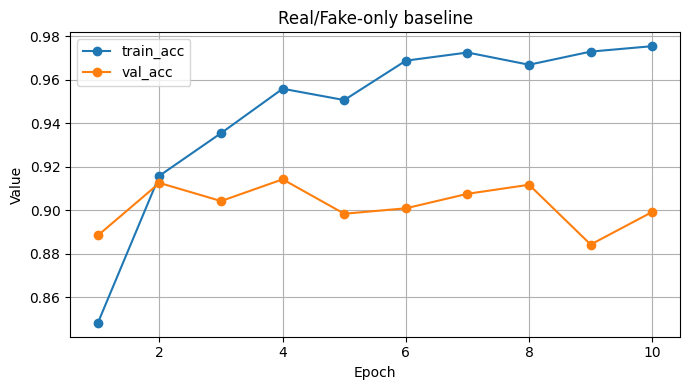


=== Baseline B: Transformation-only model ===


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[trans] Epoch 01/10 | train_loss=0.7314 train_acc=0.6737 | val_loss=0.5439 val_acc=0.7733


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[trans] Epoch 02/10 | train_loss=0.4830 train_acc=0.8017 | val_loss=0.4074 val_acc=0.8233


...

[trans] Epoch 08/10 | train_loss=0.2178 train_acc=0.9163 | val_loss=0.3165 val_acc=0.8725


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[trans] Epoch 09/10 | train_loss=0.2127 train_acc=0.9173 | val_loss=0.3030 val_acc=0.8783


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[trans] Epoch 10/10 | train_loss=0.1685 train_acc=0.9350 | val_loss=0.4012 val_acc=0.8608
Best trans baseline val accuracy: 0.8783


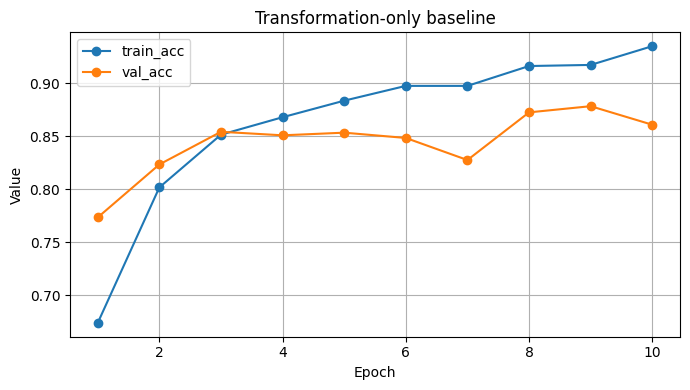

In [15]:
# Baseline A: real/fake only, trained on all transformation settings.
print("\n=== Baseline A: Real/Fake-only model ===")
rf_baseline = SingleTaskEffNet(num_classes=2, use_pretrained=USE_PRETRAINED)
rf_baseline, hist_rf, rf_baseline_path = train_single_task(
    rf_baseline,
    train_loader,
    val_loader,
    target="rf",
    epochs=EPOCHS_BASELINE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
plot_history(hist_rf, "Real/Fake-only baseline", ["train_acc", "val_acc"])

# Baseline B: transformation only, trained on all real/fake classes.
print("\n=== Baseline B: Transformation-only model ===")
trans_baseline = SingleTaskEffNet(num_classes=3, use_pretrained=USE_PRETRAINED)
trans_baseline, hist_trans, trans_baseline_path = train_single_task(
    trans_baseline,
    train_loader,
    val_loader,
    target="trans",
    epochs=EPOCHS_BASELINE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
plot_history(hist_trans, "Transformation-only baseline", ["train_acc", "val_acc"])


## 6.4 Train standard multi-task models for loss-weight ablation



=== Multi-task model | alpha=0.2 ===


/tmp/ipykernel_4985/3281784709.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))
/tmp/ipykernel_4985/3281784709.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.2] Epoch 01/10 | val_loss=0.4442 | RF=0.8400 | TRANS=0.8100 | MEAN=0.8250


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.2] Epoch 02/10 | val_loss=0.5058 | RF=0.8608 | TRANS=0.7792 | MEAN=0.8200


...

[alpha=0.2] Epoch 08/10 | val_loss=0.4020 | RF=0.8800 | TRANS=0.8508 | MEAN=0.8654


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.2] Epoch 09/10 | val_loss=0.3660 | RF=0.8767 | TRANS=0.8658 | MEAN=0.8713


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.2] Epoch 10/10 | val_loss=0.4098 | RF=0.8917 | TRANS=0.8475 | MEAN=0.8696
Best multi-task mean val accuracy for alpha=0.2: 0.8804


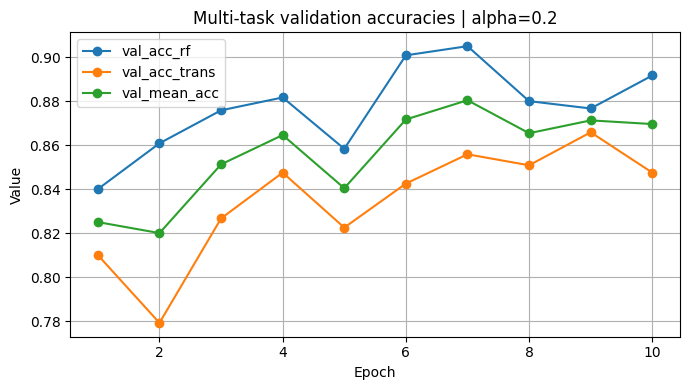


=== Multi-task model | alpha=0.5 ===


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 01/10 | val_loss=0.4112 | RF=0.8783 | TRANS=0.7808 | MEAN=0.8296


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 02/10 | val_loss=0.3497 | RF=0.8858 | TRANS=0.8117 | MEAN=0.8488


...

[alpha=0.5] Epoch 08/10 | val_loss=0.3577 | RF=0.8842 | TRANS=0.8608 | MEAN=0.8725


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 09/10 | val_loss=0.3647 | RF=0.9000 | TRANS=0.8408 | MEAN=0.8704


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 10/10 | val_loss=0.3618 | RF=0.9117 | TRANS=0.8342 | MEAN=0.8729
Best multi-task mean val accuracy for alpha=0.5: 0.8821


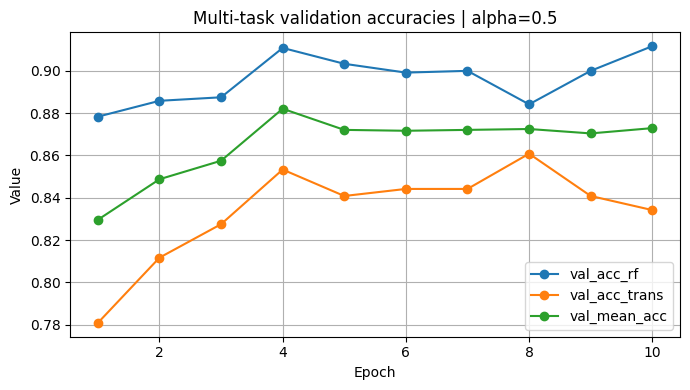


=== Multi-task model | alpha=0.8 ===


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.8] Epoch 01/10 | val_loss=0.3696 | RF=0.8850 | TRANS=0.6583 | MEAN=0.7717


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.8] Epoch 02/10 | val_loss=0.3442 | RF=0.8833 | TRANS=0.7417 | MEAN=0.8125


...

[alpha=0.8] Epoch 08/10 | val_loss=0.3562 | RF=0.8900 | TRANS=0.8192 | MEAN=0.8546


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.8] Epoch 09/10 | val_loss=0.4599 | RF=0.8817 | TRANS=0.8258 | MEAN=0.8538


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.8] Epoch 10/10 | val_loss=0.3530 | RF=0.9067 | TRANS=0.8117 | MEAN=0.8592
Best multi-task mean val accuracy for alpha=0.8: 0.8592


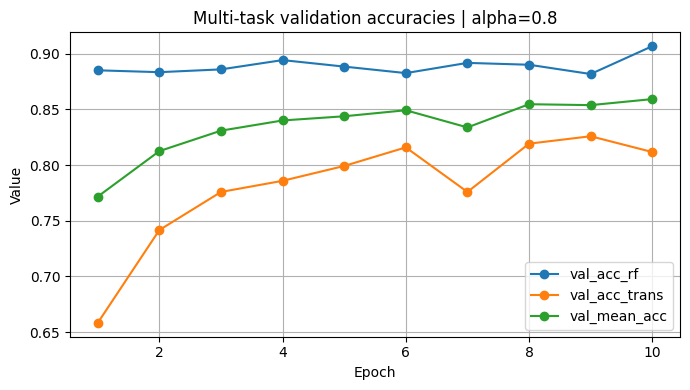

In [16]:
multitask_runs = {}

for alpha in ALPHAS:
    print(f"\n=== Multi-task model | alpha={alpha} ===")
    model = MultiTaskEffNet(use_pretrained=USE_PRETRAINED)
    model, history, ckpt_path = train_multitask(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS_MULTITASK,
        alpha=alpha,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        save_prefix="standard_multitask",
    )

    plot_history(
        history,
        title=f"Multi-task validation accuracies | alpha={alpha}",
        keys=["val_acc_rf", "val_acc_trans", "val_mean_acc"],
    )

    multitask_runs[alpha] = {
        "model": model,
        "history": history,
        "checkpoint": ckpt_path,
    }


## 6.5 Optional: train artifact-aware multi-task model


In [29]:
artifact_run = None
RUN_ARTIFACT_AWARE = True

if RUN_ARTIFACT_AWARE:
    print(f"\n=== Artifact-aware model | alpha={ARTIFACT_ALPHA} ===")
    artifact_model = ArtifactAwareMultiTaskEffNet(use_pretrained=USE_PRETRAINED)
    artifact_model, artifact_history, artifact_ckpt = train_multitask(
        artifact_model,
        train_loader,
        val_loader,
        epochs=EPOCHS_MULTITASK,
        alpha=ARTIFACT_ALPHA,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        save_prefix="artifact_aware",
    )

    artifact_run = {
        "model": artifact_model,
        "history": artifact_history,
        "checkpoint": artifact_ckpt,
    }
else:
    print("RUN_ARTIFACT_AWARE is False. Set it to True in Globals to run this optional experiment.")



=== Artifact-aware model | alpha=0.5 ===


/tmp/ipykernel_4985/3281784709.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))
/tmp/ipykernel_4985/3281784709.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 01/10 | val_loss=0.4009 | RF=0.8933 | TRANS=0.7750 | MEAN=0.8342


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 02/10 | val_loss=0.3356 | RF=0.8800 | TRANS=0.8425 | MEAN=0.8613


...

[alpha=0.5] Epoch 08/10 | val_loss=0.3198 | RF=0.9025 | TRANS=0.8533 | MEAN=0.8779


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 09/10 | val_loss=0.3505 | RF=0.8883 | TRANS=0.8542 | MEAN=0.8712


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102960000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[alpha=0.5] Epoch 10/10 | val_loss=0.3752 | RF=0.9008 | TRANS=0.8417 | MEAN=0.8713
Best multi-task mean val accuracy for alpha=0.5: 0.8779


# 7. Evaluation

Tests and analysis for trained networks: prediction functions, baseline comparison, loss-weight ablation tables, transformation-wise breakdowns, cross-class analysis, confusion matrices, and report-ready takeaways.


## 7.1 Prediction utilities


In [18]:
@torch.no_grad()
def predict_single_task(model, data_loader, target="rf"):
    assert target in {"rf", "trans"}
    model = model.to(DEVICE)
    model.eval()

    records = []
    for batch in data_loader:
        imgs, labels_rf, labels_trans, trans_names, rf_names, redigital_methods = move_batch_to_device(batch, DEVICE)
        logits = model(imgs)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        labels_rf_np = labels_rf.cpu().numpy()
        labels_trans_np = labels_trans.cpu().numpy()

        for i in range(len(preds)):
            records.append({
                "y_rf": int(labels_rf_np[i]),
                "y_trans": int(labels_trans_np[i]),
                "pred": int(preds[i]),
                "trans_name": trans_names[i],
                "rf_name": rf_names[i],
                "redigital_method": redigital_methods[i],
            })

    df = pd.DataFrame(records)
    y_col = "y_rf" if target == "rf" else "y_trans"
    acc = (df["pred"] == df[y_col]).mean()
    return acc, df

@torch.no_grad()
def predict_multitask(model, data_loader):
    model = model.to(DEVICE)
    model.eval()
    records = []

    for batch in data_loader:
        imgs, labels_rf, labels_trans, trans_names, rf_names, redigital_methods = move_batch_to_device(batch, DEVICE)
        out_rf, out_trans = model(imgs)
        pred_rf = torch.argmax(out_rf, dim=1).cpu().numpy()
        pred_trans = torch.argmax(out_trans, dim=1).cpu().numpy()

        labels_rf_np = labels_rf.cpu().numpy()
        labels_trans_np = labels_trans.cpu().numpy()

        for i in range(len(pred_rf)):
            records.append({
                "y_rf": int(labels_rf_np[i]),
                "p_rf": int(pred_rf[i]),
                "y_trans": int(labels_trans_np[i]),
                "p_trans": int(pred_trans[i]),
                "rf_name": rf_names[i],
                "trans_name": trans_names[i],
                "redigital_method": redigital_methods[i],
            })

    return pd.DataFrame(records)


## 7.2 Analysis utilities


In [19]:
def summarize_multitask_predictions(pred_df):
    """Detailed analysis required by the project statement."""
    df = pred_df.copy()
    df["rf_correct"] = df["p_rf"] == df["y_rf"]
    df["trans_correct"] = df["p_trans"] == df["y_trans"]

    overall = pd.DataFrame([{
        "count": len(df),
        "real_fake_accuracy": df["rf_correct"].mean(),
        "transformation_accuracy": df["trans_correct"].mean(),
        "mean_accuracy": (df["rf_correct"].mean() + df["trans_correct"].mean()) / 2,
    }])

    by_trans = (
        df.groupby("trans_name")
        .apply(lambda g: pd.Series({
            "count": len(g),
            "real_fake_accuracy": g["rf_correct"].mean(),
            "transformation_accuracy": g["trans_correct"].mean(),
        }))
        .reset_index()
        .sort_values("trans_name")
    )

    # This is the missing cross-class analysis:
    # Does each transformation affect real and AI-generated images differently?
    by_trans_and_rf = (
        df.groupby(["trans_name", "rf_name"])
        .apply(lambda g: pd.Series({
            "count": len(g),
            "real_fake_recall_within_group": g["rf_correct"].mean(),
            "transformation_accuracy_within_group": g["trans_correct"].mean(),
        }))
        .reset_index()
        .sort_values(["trans_name", "rf_name"])
    )

    redigital_df = df[df["trans_name"] == "redigital"]
    if len(redigital_df) > 0:
        by_redigital_method = (
            redigital_df.groupby(["redigital_method", "rf_name"])
            .apply(lambda g: pd.Series({
                "count": len(g),
                "real_fake_recall_within_group": g["rf_correct"].mean(),
                "transformation_accuracy_within_group": g["trans_correct"].mean(),
            }))
            .reset_index()
            .sort_values(["redigital_method", "rf_name"])
        )
    else:
        by_redigital_method = pd.DataFrame()

    return overall, by_trans, by_trans_and_rf, by_redigital_method


def robustness_drop_from_by_trans(by_trans):
    values = dict(zip(by_trans["trans_name"], by_trans["real_fake_accuracy"]))
    degraded = np.mean([values.get("transfer", np.nan), values.get("redigital", np.nan)])
    return values.get("original", np.nan) - degraded


## 7.3 Evaluate unimodal baselines


In [20]:
# Baseline evaluation table.
rf_acc, rf_pred_df = predict_single_task(rf_baseline, val_loader, target="rf")
trans_acc, trans_pred_df = predict_single_task(trans_baseline, val_loader, target="trans")

baseline_summary = pd.DataFrame([
    {"model": "RF-only baseline", "real_fake_accuracy": rf_acc, "transformation_accuracy": np.nan},
    {"model": "Transformation-only baseline", "real_fake_accuracy": np.nan, "transformation_accuracy": trans_acc},
])

display(baseline_summary)

print("\nReal/Fake baseline classification report:")
print(classification_report(rf_pred_df["y_rf"], rf_pred_df["pred"], target_names=["real", "ai"]))

print("\nTransformation baseline classification report:")
print(classification_report(trans_pred_df["y_trans"], trans_pred_df["pred"], target_names=["original", "transfer", "redigital"]))


,model,real_fake_accuracy,transformation_accuracy
0,RF-only baseline,0.899167,NaN
1,Transformation-only baseline,NaN,0.860833



Real/Fake baseline classification report:
              precision    recall  f1-score   support

        real       0.89      0.91      0.90       600
          ai       0.91      0.89      0.90       600

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200


Transformation baseline classification report:
              precision    recall  f1-score   support

    original       0.81      0.84      0.82       400
    transfer       0.88      0.79      0.83       400
   redigital       0.89      0.95      0.92       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200



## 7.4 Evaluate all multi-task models


In [21]:
# Evaluate every trained multi-task run and store detailed analysis tables.
for alpha, run in multitask_runs.items():
    print(f"\n=== Evaluation | Standard multi-task alpha={alpha} ===")
    pred_df = predict_multitask(run["model"], val_loader)
    overall, by_trans, by_trans_and_rf, by_redigital_method = summarize_multitask_predictions(pred_df)

    run.update({
        "pred_df": pred_df,
        "overall": overall,
        "by_trans": by_trans,
        "by_trans_and_rf": by_trans_and_rf,
        "by_redigital_method": by_redigital_method,
    })

    print(f"\nOverall metrics for alpha={alpha}")
    display(overall)
    print(f"\nReal/Fake accuracy by transformation for alpha={alpha}")
    display(by_trans)
    print(f"\nCross-class breakdown for alpha={alpha}")
    display(by_trans_and_rf)
    if not by_redigital_method.empty:
        print(f"\nBreakdown by redigital sub-method for alpha={alpha}")
        display(by_redigital_method)



=== Evaluation | Standard multi-task alpha=0.2 ===

Overall metrics for alpha=0.2


/tmp/ipykernel_4985/2422526643.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_4985/2422526643.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_4985/2422526643.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the gr

,count,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,1200,0.891667,0.8475,0.869583



Real/Fake accuracy by transformation for alpha=0.2


,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.8850,0.7575
1,redigital,400.0,0.8775,0.8700
2,transfer,400.0,0.9125,0.9150


...

,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.9125,0.7875
1,redigital,400.0,0.9000,0.8200
2,transfer,400.0,0.9075,0.8275



Cross-class breakdown for alpha=0.8


,trans_name,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,original,ai,200.0,0.900,0.870
1,original,real,200.0,0.925,0.705
2,redigital,ai,200.0,0.960,0.885
3,redigital,real,200.0,0.840,0.755
4,transfer,ai,200.0,0.880,0.855
5,transfer,real,200.0,0.935,0.800



Breakdown by redigital sub-method for alpha=0.8


,redigital_method,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,redigital_all,ai,200.0,0.96,0.885
1,redigital_all,real,200.0,0.84,0.755


## 7.5 Loss-weight ablation summary


In [22]:
# Ablation summary table: required for the final report/presentation.
ablation_rows = []
for alpha, run in multitask_runs.items():
    overall = run["overall"].iloc[0]
    history = run["history"]
    best_epoch = int(np.argmax(history["val_mean_acc"]) + 1)
    drop = robustness_drop_from_by_trans(run["by_trans"])
    ablation_rows.append({
        "alpha": alpha,
        "best_epoch_by_mean_acc": best_epoch,
        "real_fake_accuracy": overall["real_fake_accuracy"],
        "transformation_accuracy": overall["transformation_accuracy"],
        "mean_accuracy": overall["mean_accuracy"],
        "robustness_drop_original_minus_degraded": drop,
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values("alpha")
display(ablation_df)

best_alpha = ablation_df.sort_values("mean_accuracy", ascending=False).iloc[0]["alpha"]
best_alpha = float(best_alpha)
print(f"Best alpha by mean accuracy: {best_alpha}")


,alpha,best_epoch_by_mean_acc,real_fake_accuracy,transformation_accuracy,mean_accuracy,robustness_drop_original_minus_degraded
0,0.2,7,0.891667,0.847500,0.869583,-0.01000
1,0.5,4,0.911667,0.834167,0.872917,0.00500
2,0.8,10,0.906667,0.811667,0.859167,0.00875


Best alpha by mean accuracy: 0.5


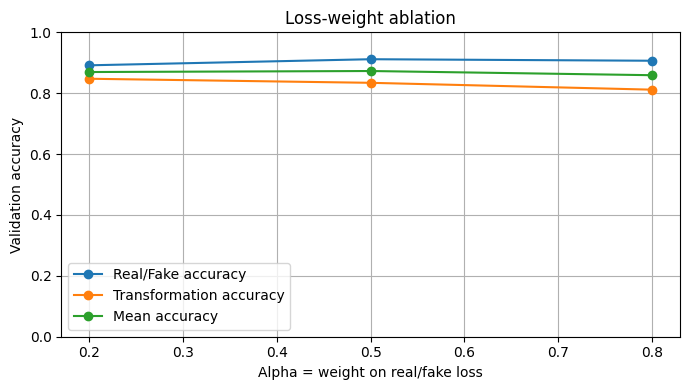

In [23]:
# Plot alpha trade-off.
plt.figure(figsize=(7, 4))
plt.plot(ablation_df["alpha"], ablation_df["real_fake_accuracy"], marker="o", label="Real/Fake accuracy")
plt.plot(ablation_df["alpha"], ablation_df["transformation_accuracy"], marker="o", label="Transformation accuracy")
plt.plot(ablation_df["alpha"], ablation_df["mean_accuracy"], marker="o", label="Mean accuracy")
plt.xlabel("Alpha = weight on real/fake loss")
plt.ylabel("Validation accuracy")
plt.title("Loss-weight ablation")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 7.6 Final comparison: baselines vs multi-task models


In [24]:
comparison_rows = [
    {"model": "RF-only baseline", "alpha": np.nan, "real_fake_accuracy": rf_acc, "transformation_accuracy": np.nan, "mean_accuracy": np.nan},
    {"model": "Transformation-only baseline", "alpha": np.nan, "real_fake_accuracy": np.nan, "transformation_accuracy": trans_acc, "mean_accuracy": np.nan},
]

for alpha, run in multitask_runs.items():
    o = run["overall"].iloc[0]
    comparison_rows.append({
        "model": "Standard multi-task",
        "alpha": alpha,
        "real_fake_accuracy": o["real_fake_accuracy"],
        "transformation_accuracy": o["transformation_accuracy"],
        "mean_accuracy": o["mean_accuracy"],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,model,alpha,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,RF-only baseline,NaN,0.899167,NaN,NaN
1,Transformation-only baseline,NaN,NaN,0.860833,NaN
2,Standard multi-task,0.2,0.891667,0.847500,0.869583
3,Standard multi-task,0.5,0.911667,0.834167,0.872917
4,Standard multi-task,0.8,0.906667,0.811667,0.859167


## 7.7 Detailed analysis for the selected model


In [25]:
# Detailed analysis for the selected/best alpha.
selected_run = multitask_runs[best_alpha]
print(f"Selected alpha for detailed analysis: {best_alpha}")

print("\nOverall:")
display(selected_run["overall"])

print("\nBy transformation:")
display(selected_run["by_trans"])

print("\nBy transformation and real/fake class:")
display(selected_run["by_trans_and_rf"])

if not selected_run["by_redigital_method"].empty:
    print("\nBy redigital sub-method and real/fake class:")
    display(selected_run["by_redigital_method"])


Selected alpha for detailed analysis: 0.5

Overall:


,count,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,1200,0.911667,0.834167,0.872917



By transformation:


,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.9150,0.8375
1,redigital,400.0,0.8925,0.7725
2,transfer,400.0,0.9275,0.8925



By transformation and real/fake class:


,trans_name,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,original,ai,200.0,0.915,0.920
1,original,real,200.0,0.915,0.755
2,redigital,ai,200.0,0.885,0.850
3,redigital,real,200.0,0.900,0.695
4,transfer,ai,200.0,0.920,0.940
5,transfer,real,200.0,0.935,0.845



By redigital sub-method and real/fake class:


,redigital_method,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,redigital_all,ai,200.0,0.885,0.850
1,redigital_all,real,200.0,0.900,0.695


## 7.8 Confusion matrices


In [26]:
# Confusion matrices for the selected multi-task model.
pred_df = selected_run["pred_df"]

cm_rf = confusion_matrix(pred_df["y_rf"], pred_df["p_rf"])
cm_trans = confusion_matrix(pred_df["y_trans"], pred_df["p_trans"])

print("Real/Fake confusion matrix: rows=true, cols=pred")
display(pd.DataFrame(cm_rf, index=["true_real", "true_ai"], columns=["pred_real", "pred_ai"]))

print("\nTransformation confusion matrix: rows=true, cols=pred")
display(pd.DataFrame(
    cm_trans,
    index=["true_original", "true_transfer", "true_redigital"],
    columns=["pred_original", "pred_transfer", "pred_redigital"],
))


Real/Fake confusion matrix: rows=true, cols=pred


,pred_real,pred_ai
true_real,550,50
true_ai,56,544



Transformation confusion matrix: rows=true, cols=pred


,pred_original,pred_transfer,pred_redigital
true_original,335,59,6
true_transfer,40,357,3
true_redigital,76,15,309


## 7.9 Optional artifact-aware evaluation


In [30]:
if RUN_ARTIFACT_AWARE and artifact_run is not None:
    artifact_pred_df = predict_multitask(artifact_run["model"], val_loader)
    artifact_overall, artifact_by_trans, artifact_by_trans_and_rf, artifact_by_redigital = summarize_multitask_predictions(artifact_pred_df)

    if ARTIFACT_ALPHA not in multitask_runs:
        raise ValueError("ARTIFACT_ALPHA must be one of the values in ALPHAS to make a fair comparison.")

    standard_same_alpha = multitask_runs[ARTIFACT_ALPHA]

    print("\nStandard multi-task, same alpha:")
    display(standard_same_alpha["overall"])
    display(standard_same_alpha["by_trans"])

    print("\nArtifact-aware multi-task:")
    display(artifact_overall)
    display(artifact_by_trans)
    display(artifact_by_trans_and_rf)

    comparison_artifact = pd.DataFrame([
        {
            "model": "Standard multi-task",
            "alpha": ARTIFACT_ALPHA,
            "real_fake_accuracy": standard_same_alpha["overall"].iloc[0]["real_fake_accuracy"],
            "transformation_accuracy": standard_same_alpha["overall"].iloc[0]["transformation_accuracy"],
            "mean_accuracy": standard_same_alpha["overall"].iloc[0]["mean_accuracy"],
            "robustness_drop": robustness_drop_from_by_trans(standard_same_alpha["by_trans"]),
        },
        {
            "model": "Artifact-aware multi-task",
            "alpha": ARTIFACT_ALPHA,
            "real_fake_accuracy": artifact_overall.iloc[0]["real_fake_accuracy"],
            "transformation_accuracy": artifact_overall.iloc[0]["transformation_accuracy"],
            "mean_accuracy": artifact_overall.iloc[0]["mean_accuracy"],
            "robustness_drop": robustness_drop_from_by_trans(artifact_by_trans),
        },
    ])

    print("\nFair architecture comparison with the same alpha:")
    display(comparison_artifact)
else:
    print("Artifact-aware evaluation skipped.")



Standard multi-task, same alpha:


/tmp/ipykernel_4985/2422526643.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_4985/2422526643.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/tmp/ipykernel_4985/2422526643.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the gr

,count,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,1200,0.911667,0.834167,0.872917


,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.9150,0.8375
1,redigital,400.0,0.8925,0.7725
2,transfer,400.0,0.9275,0.8925



Artifact-aware multi-task:


,count,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,1200,0.900833,0.841667,0.87125


,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.8875,0.770
1,redigital,400.0,0.8925,0.925
2,transfer,400.0,0.9225,0.830


,trans_name,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,original,ai,200.0,0.855,0.810
1,original,real,200.0,0.920,0.730
2,redigital,ai,200.0,0.855,0.970
3,redigital,real,200.0,0.930,0.880
4,transfer,ai,200.0,0.940,0.915
5,transfer,real,200.0,0.905,0.745



Fair architecture comparison with the same alpha:


,model,alpha,real_fake_accuracy,transformation_accuracy,mean_accuracy,robustness_drop
0,Standard multi-task,0.5,0.911667,0.834167,0.872917,0.005
1,Artifact-aware multi-task,0.5,0.900833,0.841667,0.871250,-0.020


## 7.10 Report-ready takeaways


In [28]:
print("Use these values in the report/presentation after the notebook finishes running.")

print("\n1) Baseline comparison")
display(comparison_df)

print("\n2) Loss-weight ablation")
display(ablation_df)

print("\n3) Best multi-task detailed breakdown")
display(selected_run["by_trans"])
display(selected_run["by_trans_and_rf"])

print("\nSuggested interpretation template:")
print(f"- Best alpha by mean accuracy: {best_alpha}")
print("- Compare RF-only vs multi-task RF accuracy to see whether joint learning helps real/fake detection.")
print("- Compare transformation-only vs multi-task transformation accuracy to see whether the tasks compete or complement each other.")
print("- Inspect the by-transformation and by-real/fake tables to identify which post-processing condition damages detection the most.")
print("- If redigital sub-methods are available, report which re-digitization setting is most harmful.")


Use these values in the report/presentation after the notebook finishes running.

1) Baseline comparison


,model,alpha,real_fake_accuracy,transformation_accuracy,mean_accuracy
0,RF-only baseline,NaN,0.899167,NaN,NaN
1,Transformation-only baseline,NaN,NaN,0.860833,NaN
2,Standard multi-task,0.2,0.891667,0.847500,0.869583
3,Standard multi-task,0.5,0.911667,0.834167,0.872917
4,Standard multi-task,0.8,0.906667,0.811667,0.859167



2) Loss-weight ablation


,alpha,best_epoch_by_mean_acc,real_fake_accuracy,transformation_accuracy,mean_accuracy,robustness_drop_original_minus_degraded
0,0.2,7,0.891667,0.847500,0.869583,-0.01000
1,0.5,4,0.911667,0.834167,0.872917,0.00500
2,0.8,10,0.906667,0.811667,0.859167,0.00875



3) Best multi-task detailed breakdown


,trans_name,count,real_fake_accuracy,transformation_accuracy
0,original,400.0,0.9150,0.8375
1,redigital,400.0,0.8925,0.7725
2,transfer,400.0,0.9275,0.8925


,trans_name,rf_name,count,real_fake_recall_within_group,transformation_accuracy_within_group
0,original,ai,200.0,0.915,0.920
1,original,real,200.0,0.915,0.755
2,redigital,ai,200.0,0.885,0.850
3,redigital,real,200.0,0.900,0.695
4,transfer,ai,200.0,0.920,0.940
5,transfer,real,200.0,0.935,0.845



Suggested interpretation template:
- Best alpha by mean accuracy: 0.5
- Compare RF-only vs multi-task RF accuracy to see whether joint learning helps real/fake detection.
- Compare transformation-only vs multi-task transformation accuracy to see whether the tasks compete or complement each other.
- Inspect the by-transformation and by-real/fake tables to identify which post-processing condition damages detection the most.
- If redigital sub-methods are available, report which re-digitization setting is most harmful.
